# Plotting Code for the Advanced Methods (Only on Essential, Not all perturbations)

In [1]:
import json
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [2]:
lasso_or_knn = "knn"

## Filtering

In [3]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/advanced_essential_lfc.csv", index_col=0)

In [4]:
def process_diffusion_entries(df):
    """
    Filter Diffusion_V1 and Diffusion_R2 entries by cell type and rename to Latent Diffusion
    
    Diffusion_V1: Keep only K-562 and hTERT-RPE1
    Diffusion_R2: Keep only Hep-G2 and Jurkat
    """
    
    # Make a copy to avoid modifying the original
    df_processed = df.copy()
    
    # First, identify which column contains the cell type information
    # It appears to be in the 'fold' column (e.g., 'K-562.0', 'hTERT-RPE1.0')
    # or in the 'cell_line' column
    
    # Extract cell type from 'fold' column (remove the decimal part)
    df_processed['cell_type'] = df_processed['fold'].apply(
        lambda x: x.rsplit('.', 1)[0] if pd.notna(x) and isinstance(x, str) else x
    )
    
    # Also check if cell_line column has values
    df_processed['cell_type'] = df_processed['cell_type'].fillna(df_processed['cell_line'])
    
    # Find indices of Diffusion_V1 and Diffusion_R2 rows
    diffusion_v1_mask = df_processed['name'] == 'Diffusion_V1'
    diffusion_r2_mask = df_processed['name'] == 'Diffusion_R2'
    
    # Filter Diffusion_V1: Keep only K-562 and hTERT-RPE1
    v1_keep_mask = diffusion_v1_mask & df_processed['cell_type'].isin(['K-562', 'hTERT-RPE1'])
    
    # Filter Diffusion_R2: Keep only Hep-G2 and Jurkat
    r2_keep_mask = diffusion_r2_mask & df_processed['cell_type'].isin(['Hep-G2', 'Jurkat'])
    
    # Rows to remove (Diffusion_V1 and Diffusion_R2 rows that don't match the criteria)
    rows_to_remove = (diffusion_v1_mask | diffusion_r2_mask) & ~(v1_keep_mask | r2_keep_mask)
    
    # Remove those rows
    df_processed = df_processed[~rows_to_remove].copy()
    
    # Rename both Diffusion_V1 and Diffusion_R2 to 'Latent Diffusion'
    df_processed.loc[v1_keep_mask[~rows_to_remove], 'name'] = 'Latent Diffusion'
    df_processed.loc[r2_keep_mask[~rows_to_remove], 'name'] = 'Latent Diffusion'
    
    # Drop the temporary cell_type column
    df_processed = df_processed.drop('cell_type', axis=1)


    # Step 1: Create masks for Schrodinger entries
    schrodinger_v1_mask = df_processed['name'] == 'Schrodinger_V1'
    schrodinger_r2_mask = df_processed['name'] == 'Schrodinger_R2'

    # Step 2: Determine which rows to keep
    # Keep Schrodinger_V1 ONLY for fold K-562.1
    schrodinger_v1_keep = schrodinger_v1_mask & (df_processed['fold'] == 'K-562.1')

    # Keep Schrodinger_R2 for all folds EXCEPT K-562.1
    schrodinger_r2_keep = schrodinger_r2_mask & (df_processed['fold'] != 'K-562.1')

    # Step 3: Remove Schrodinger rows that don't meet the criteria
    schrodinger_remove = (schrodinger_v1_mask | schrodinger_r2_mask) & ~(schrodinger_v1_keep | schrodinger_r2_keep)
    df_processed = df_processed[~schrodinger_remove].copy()

    # Step 4: Rename both Schrodinger_V1 and Schrodinger_R2 to 'Schrödinger Bridge'
    df_processed.loc[df_processed['name'].isin(['Schrodinger_V1', 'Schrodinger_R2']), 'name'] = 'Schrödinger Bridge'

    
    return df_processed

df = process_diffusion_entries(df)

In [5]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn): v
    for k, v in fig_index["advanced_methods"].items()
}
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])

## Plotting

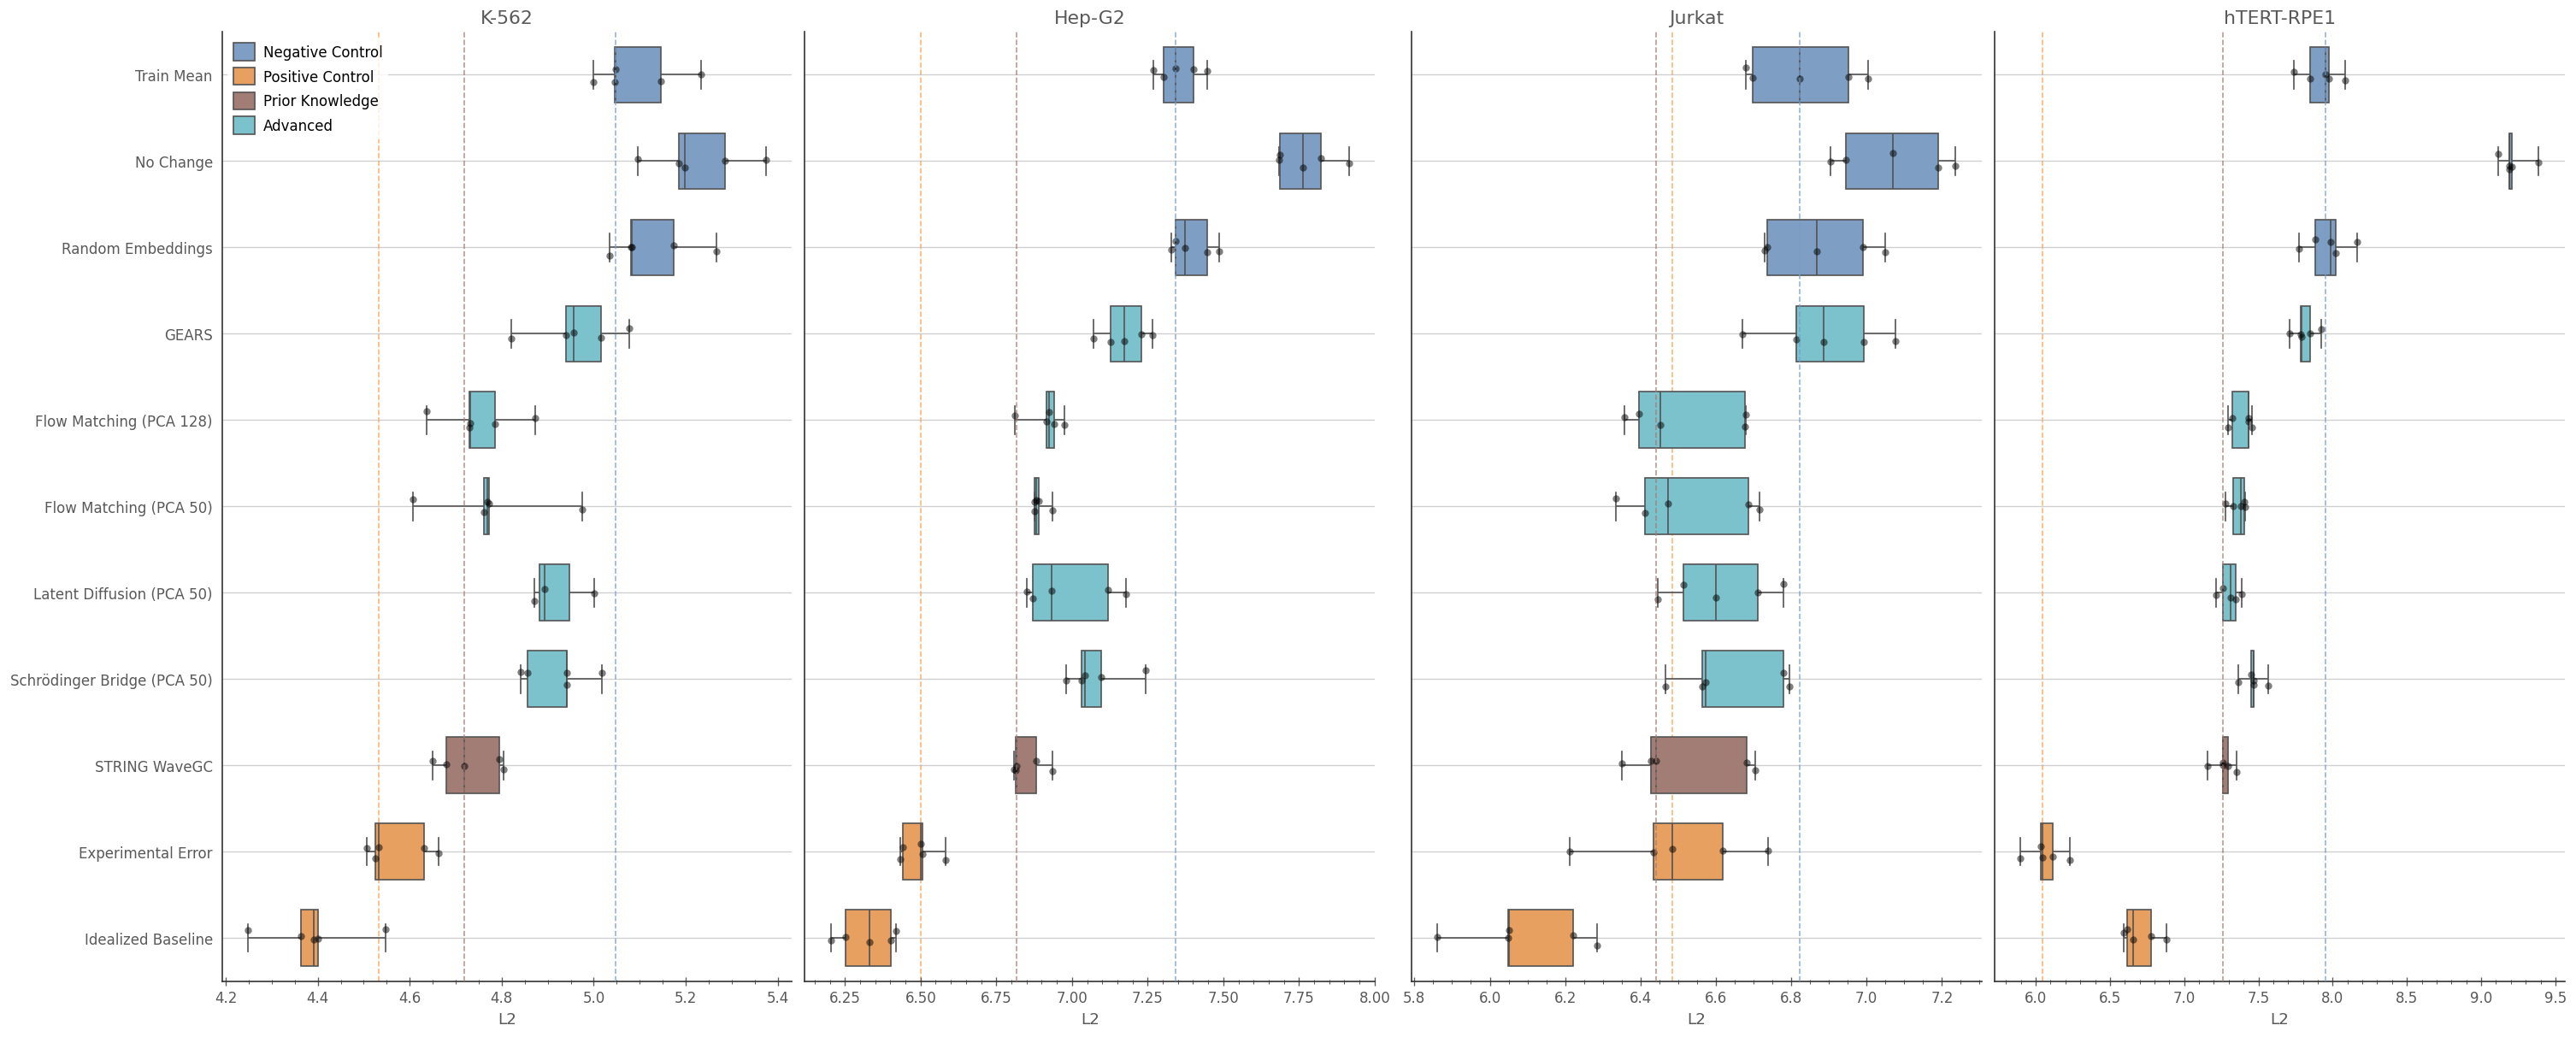

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(25, 10), constrained_layout=True)
for i, cell_line in enumerate(["K-562", "Hep-G2", "Jurkat", "hTERT-RPE1"]):

    # Build the dataframe
    method_list = [e.replace("CELL_LINE", cell_line) for e in method_map]
    idx = df["fold"].str.contains(cell_line) & df["name"].isin(method_list)
    df_subset = df[idx].copy()
    df_subset["name"] = df_subset["name"].str.replace(cell_line, "CELL_LINE")
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

    # Boxplot
    g = sns.boxplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        hue="Model type",
        x="L2",
        ax=axes[i],
        whis=(0, 100),
        width=0.65, 
        palette=model_type_palette
    )

    # Overlay datapoints
    sns.stripplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        color="black",
        alpha=0.5,
        x="L2",
        ax=axes[i],
    )

    # Decorate
    g.grid(axis="y")
    g.set(ylabel=None, title=cell_line)
    g.legend(title=None)
    if i > 0:
        g.set(yticklabels=[])
        g.legend().remove()
    
    # Get the best model
    best_mask = (
        (df_subset["Model type"] != "Positive Control") &
        (df_subset["Model type"] != "Fusion")
    )
    best_group = (
        df_subset.loc[best_mask]
        .groupby("name")["L2"]
        .median()
    )
    best_name = best_group.idxmin()
    best_level = best_group.loc[best_name]
    best_model_type = (
        df_subset.loc[df_subset["name"] == best_name, "Model type"]
        .iloc[0]
    )

    # Draw vertical lines
    train_mean_level = df_subset[df_subset["name"] == "Train Mean"]["L2"].median()
    g.axvline(train_mean_level, color=model_type_palette["Negative Control"], linestyle="--", linewidth=1, zorder=99, alpha=.75)
    exp_err_level = df_subset[df_subset["name"] == f"Experimental Error"]["L2"].median()
    g.axvline(exp_err_level, color=model_type_palette["Positive Control"], linestyle="--", linewidth=1, zorder=-99, alpha=.75)
    g.axvline(best_level, color=model_type_palette[best_model_type], linestyle="--", linewidth=1, zorder=99, alpha=.75)
plt.savefig("fig_A14.pdf")